# Housing Cost Burden and Economic Vulnerability in California
County-level analysis using Census ACS, HUD Fair Market Rents, and BLS LAUS data (2012–2023)
696 county-year observations across 58 California counties

In [1]:
import sys
import os

# notebook lives in root, src/ is one level down
sys.path.insert(0, 'src')

# override data and results paths to work from root
os.chdir(os.path.dirname(os.path.abspath('results.ipynb')))

import pandas as pd
from IPython.display import Image

from config import DATA_DIR, RESULTS_DIR, CLUSTERED_FILE
from analyze import (plot_cluster_summary, plot_counties_by_tier,
                     plot_tier_over_time, plot_california_map,
                     get_tier_summary, get_counties_by_tier)

# patch paths for notebook context
DATA_DIR = "../data"
RESULTS_DIR = "../results"
CLUSTERED_FILE = "ca_housing_clustered.csv"

## Step 1: Load the clustered dataset
Run main.py first to generate this file.

In [2]:
# load the already-processed and clustered data saved by main.py
df = pd.read_csv(os.path.join(DATA_DIR, CLUSTERED_FILE))
print(df.shape)
df.head()

(693, 9)


,fips2010,county_name,median_gross_rent,renter_burden_count,year,fmr_2br,unemployment_rate,cluster,policy_tier
0,604799999,Merced,832,9081,2012,789.0,16.4,0,High unemployment burden
1,604399999,Mariposa,797,330,2012,831.0,12.3,0,High unemployment burden
2,611599999,Yuba,870,2119,2012,857.0,15.4,0,High unemployment burden
3,601399999,Contra Costa,1340,33316,2012,1402.0,9.0,2,Low burden
4,603599999,Lassen,873,1036,2012,887.0,12.5,0,High unemployment burden


In [3]:
# confirm we have the expected shape: 693 rows (58 counties x 12 years, minus a few missing values)
print(f"rows: {df.shape[0]}, columns: {df.shape[1]}")
print(f"years covered: {sorted(df['year'].unique())}")
print(f"counties: {df['county_name'].nunique()}")
print(f"policy tiers: {sorted(df['policy_tier'].unique())}")

rows: 693, columns: 9
years covered: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
counties: 58
policy tiers: ['High rent burden', 'High unemployment burden', 'Low burden', 'Moderate rent burden']


## Step 2: Summary statistics by policy tier

In [4]:
summary = get_tier_summary(df)
print(summary)

                          median_gross_rent  fmr_2br  unemployment_rate
policy_tier                                                            
High rent burden                    2204.75  2831.31               4.17
High unemployment burden             913.89   892.59              13.40
Low burden                          1061.66  1042.27               7.04
Moderate rent burden                1605.47  1728.13               5.29


## Step 3: County tier assignments (2023)

## Step 4: Visualizations

### 1. Cluster Summary: Avg Rent and Unemployment by Policy Tier

Saved cluster summary chart to ../results/cluster_summary.png


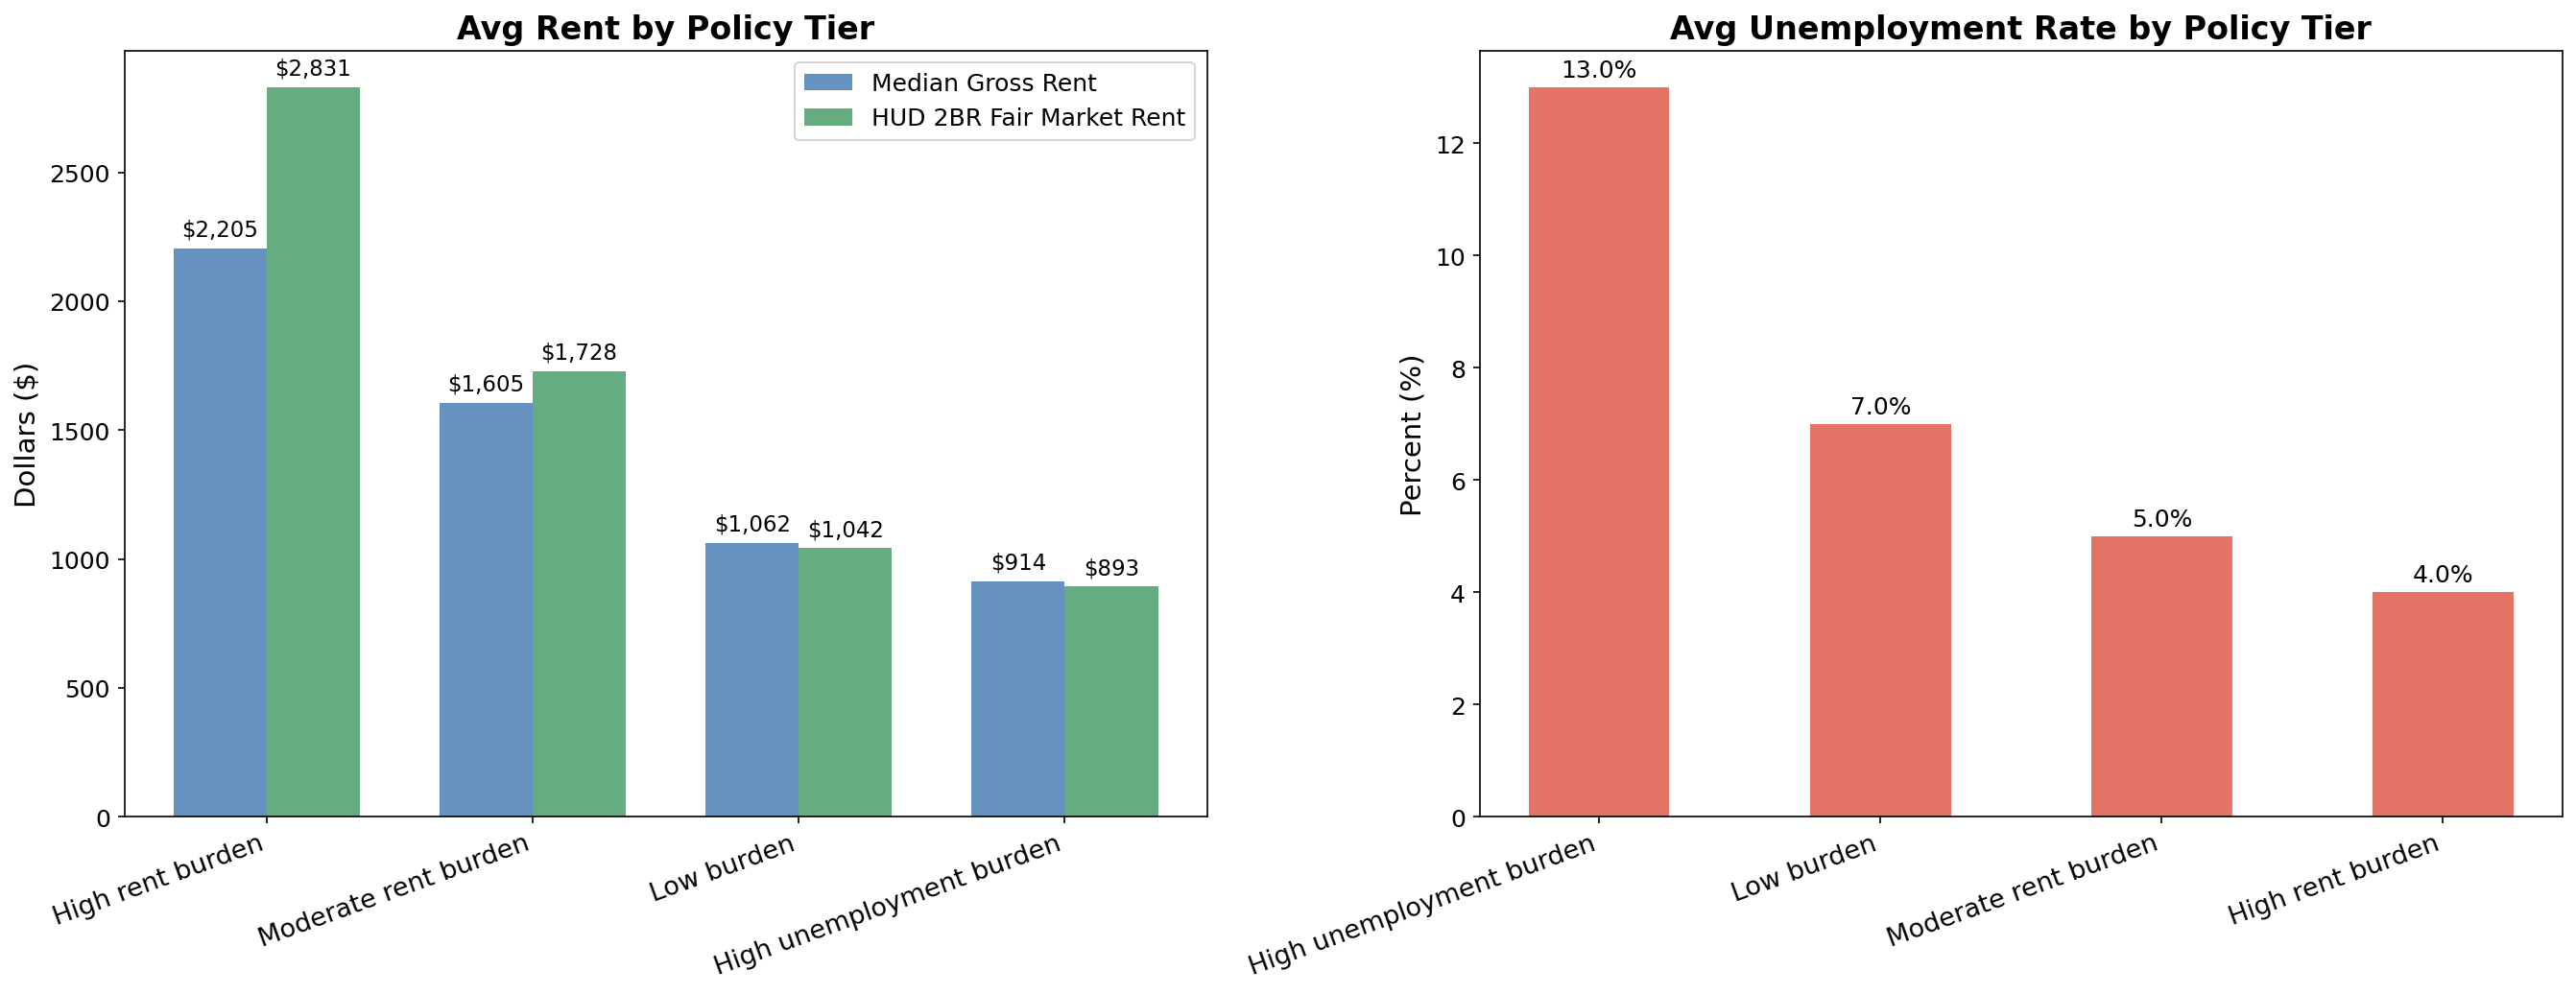

In [6]:
plot_cluster_summary(df)
Image(os.path.join(RESULTS_DIR, 'cluster_summary.png'))

### 2. County Scatter Plot: Unemployment vs Rent (2023)

Saved county scatter plot to ../results/counties_by_tier_2023.png


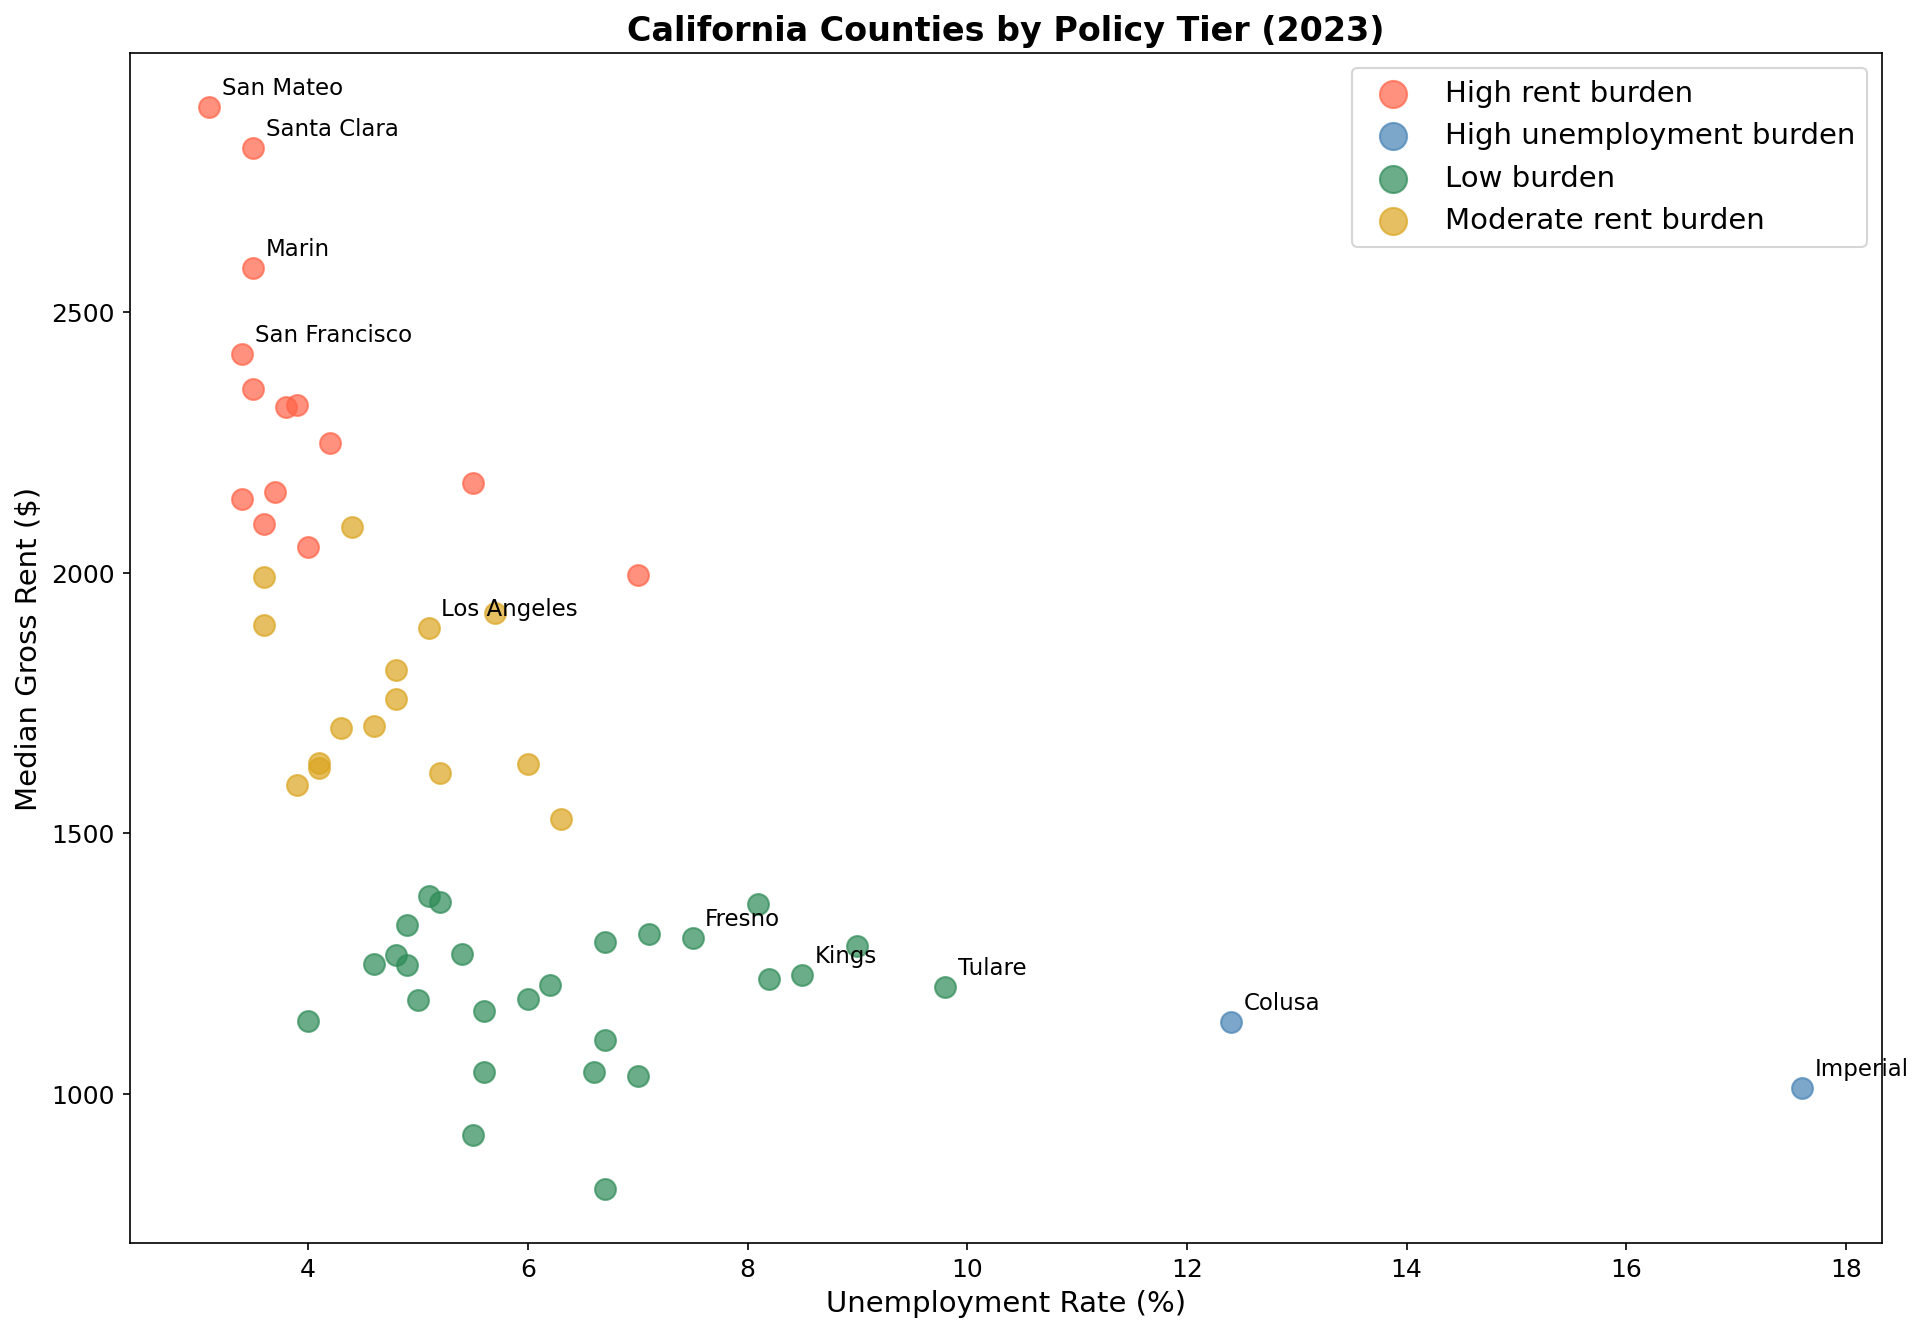

In [7]:
plot_counties_by_tier(df)
Image(os.path.join(RESULTS_DIR, 'counties_by_tier_2023.png'))

### 3. Tier Over Time: County Counts per Tier (2012–2023)

Saved tier over time chart to ../results/tier_over_time.png


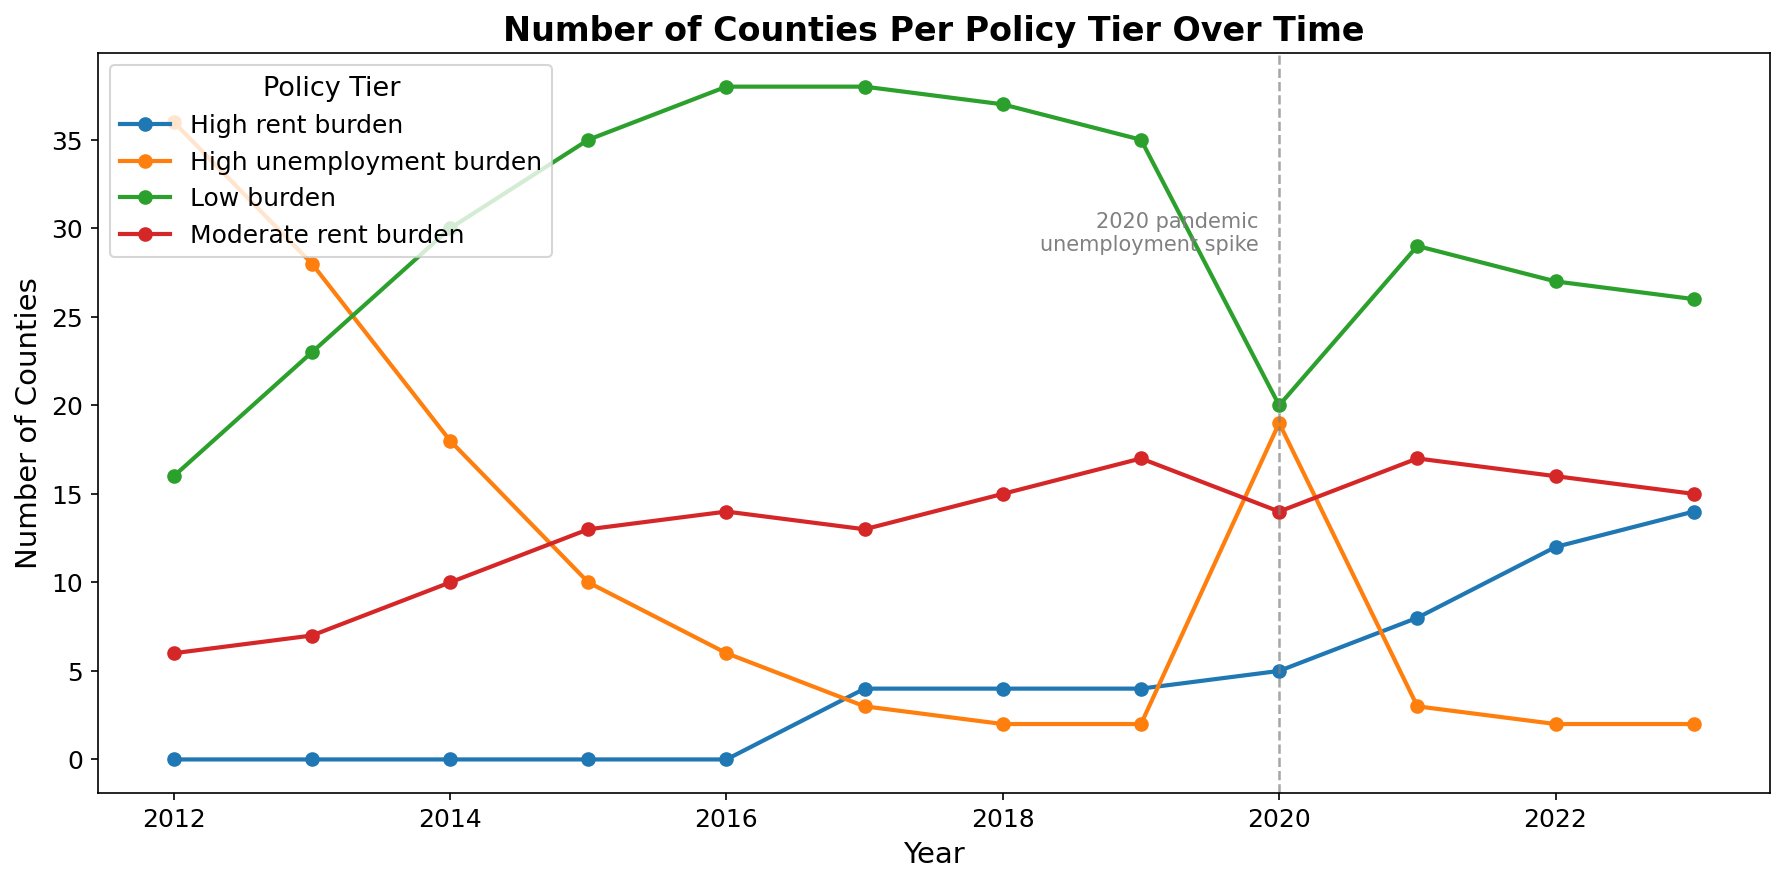

In [8]:
plot_tier_over_time(df)
Image(os.path.join(RESULTS_DIR, 'tier_over_time.png'))

### 4. California Map: Policy Tier by County (2023)

Saved california map to ../results/ca_map_2023.png


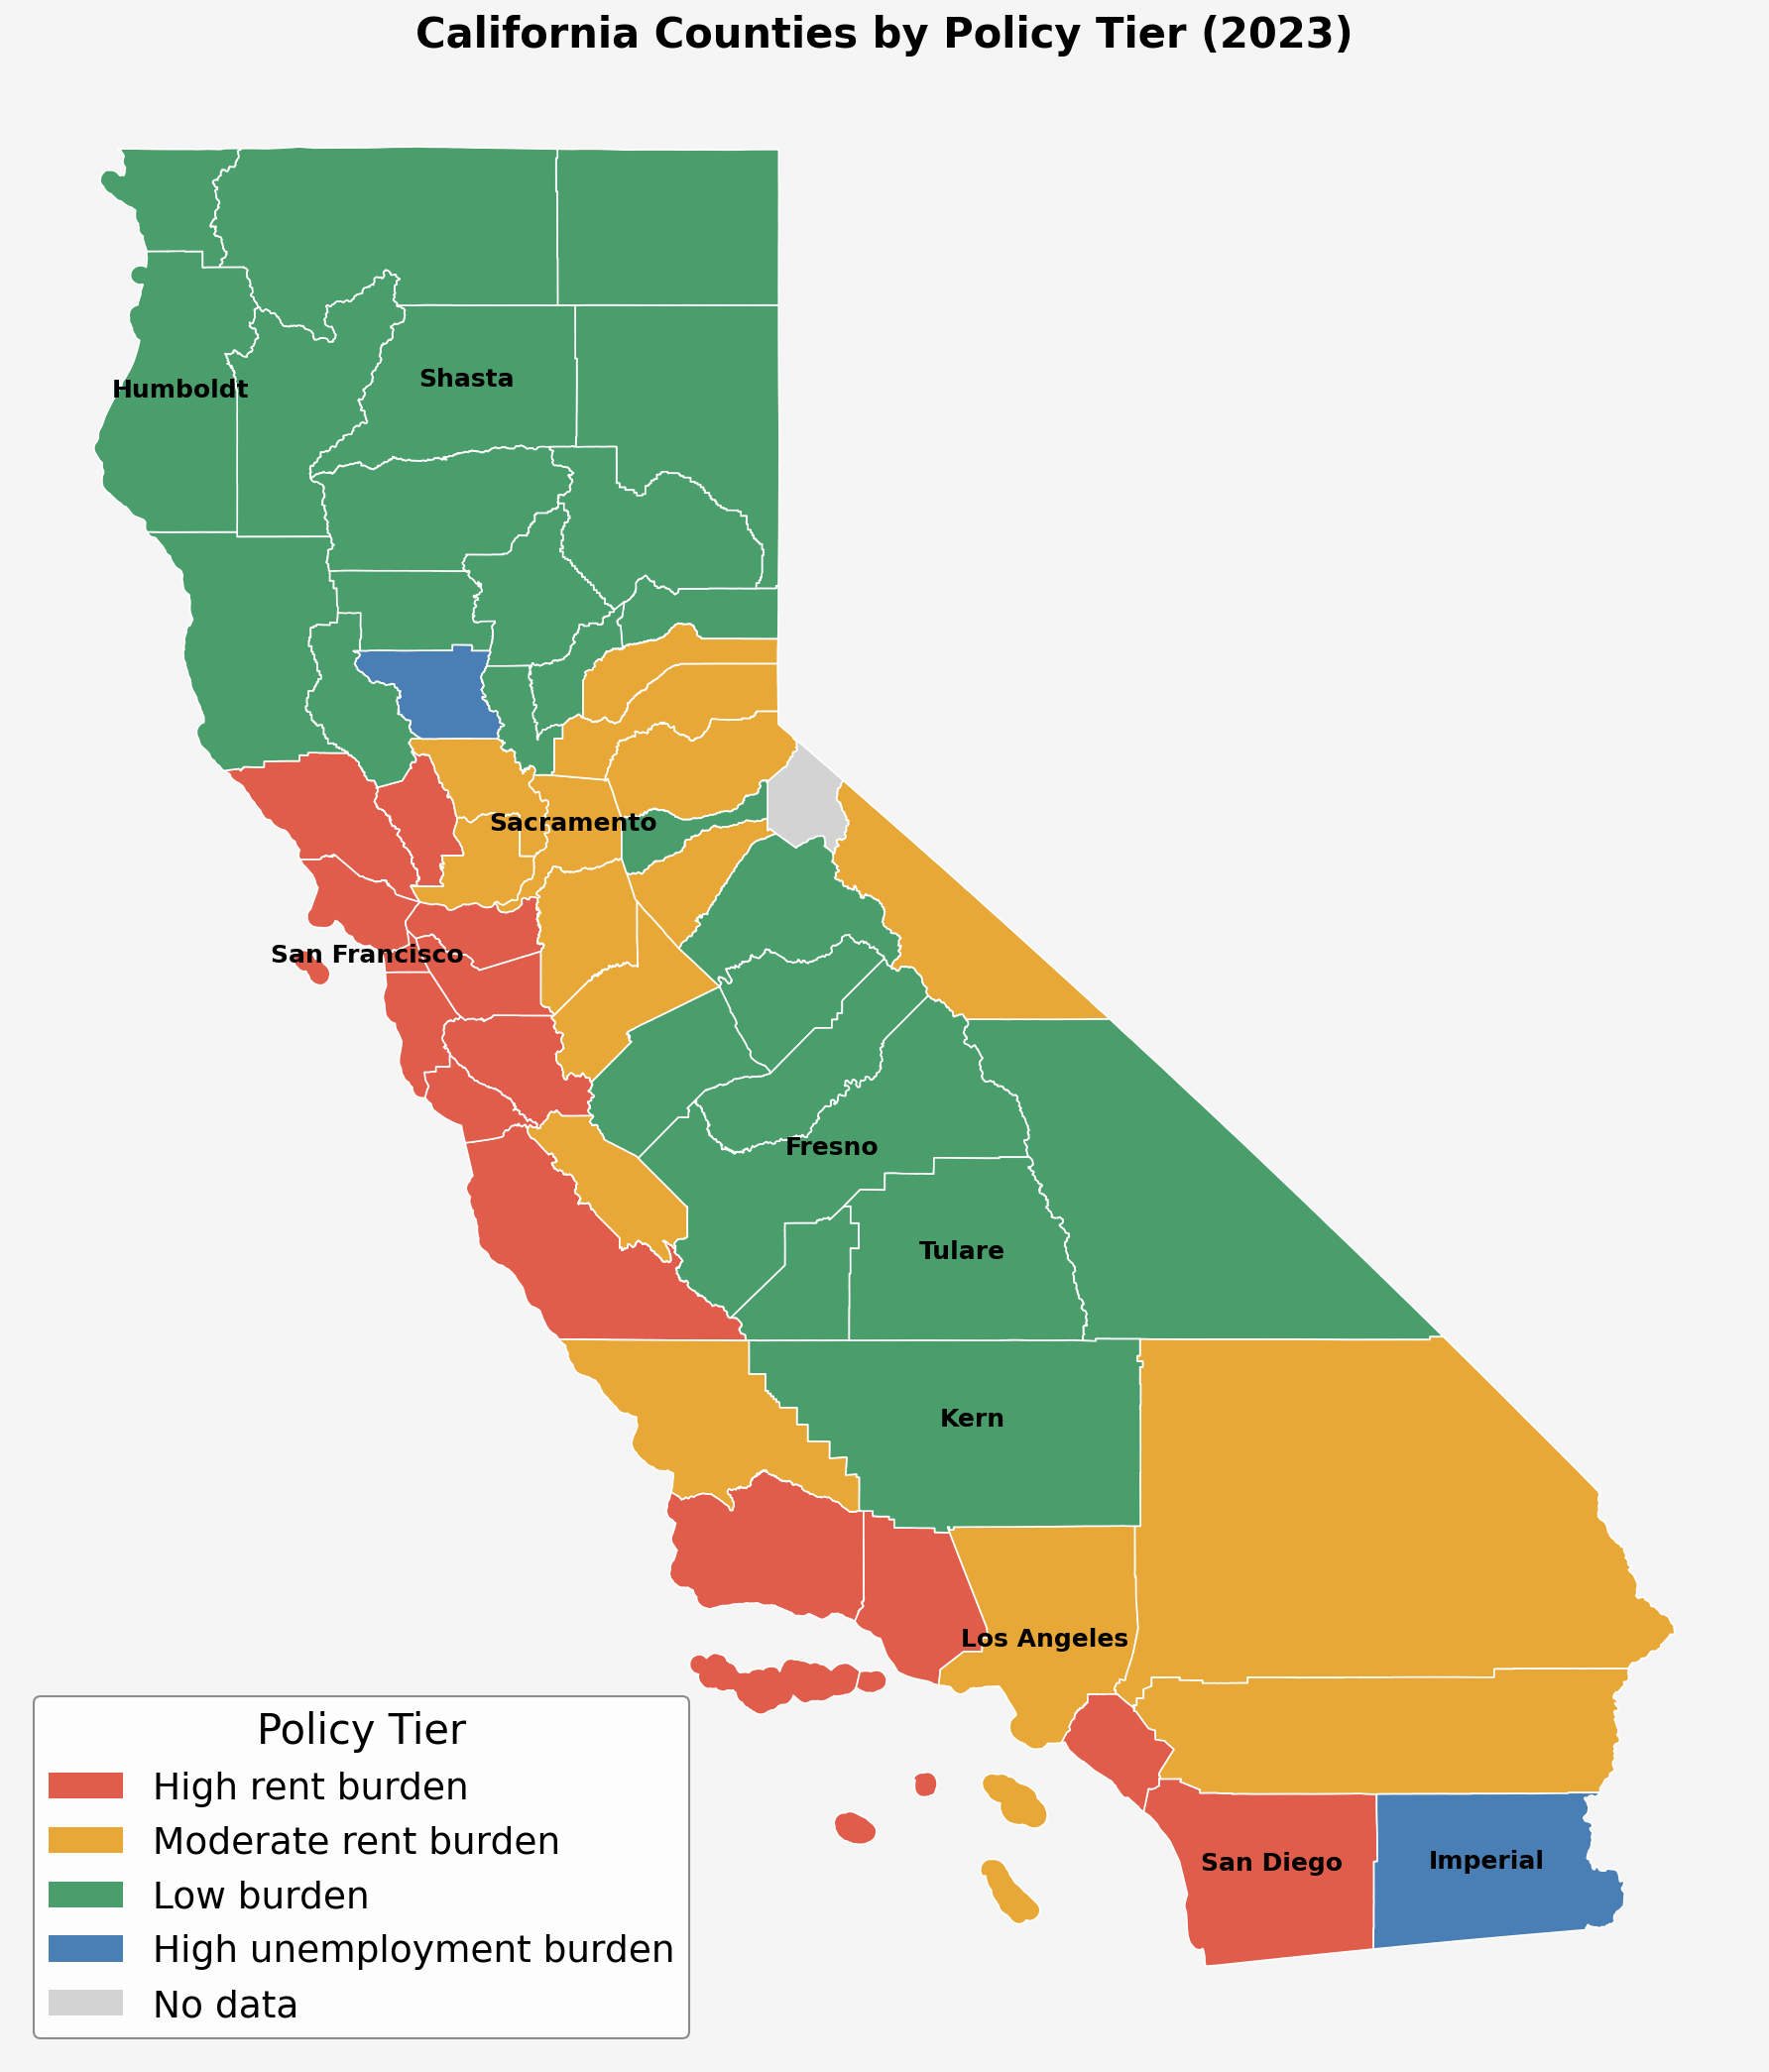

In [9]:
plot_california_map(df)
Image(os.path.join(RESULTS_DIR, 'ca_map_2023.png'))